In [5]:
import numpy as np
import pandas as pd
from keras.layers import Dense, LSTM
import matplotlib.pyplot as plt
import tensorflow as tf

In [6]:
df = pd.read_csv('https://drive.google.com/uc?id=15RfMD9lNkpS3cVN7j3_dsJKZ8_5RJG5z')
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [3]:
df.isnull().sum()

date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

- fitur: meantemp
- interval waktu: date

In [5]:
dates = df['date'].values
temp = df['meantemp'].values

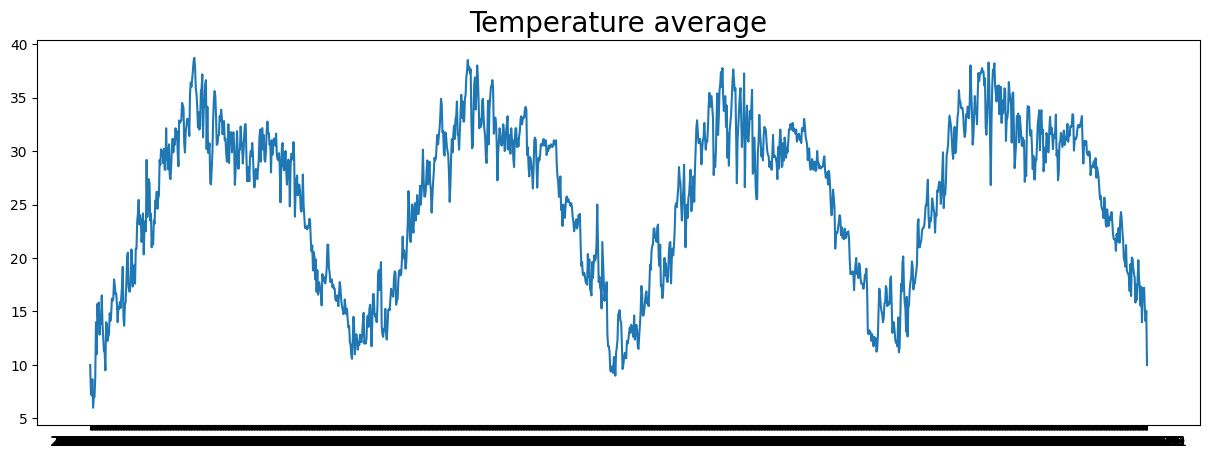

In [6]:
plt.figure(figsize=(15,5))
plt.plot(dates, temp)
plt.title('Temperature average',
     fontsize=20);

windowing

In [7]:
def windowed_dataset(series, window_size, batch_size, shuffle_buffer):
  series = tf.expand_dims(series, axis=-1)
  ds = tf.data.Dataset.from_tensor_slices(series)
  ds = ds.window(window_size + 1, shift=1, drop_remainder=True)
  ds = ds.flat_map(lambda w: w.batch(window_size + 1))
  ds = ds.shuffle(shuffle_buffer)
  ds = ds.map(lambda w: (w[:-1], w[-1:]))
  return ds.batch(batch_size).prefetch(1)

### arsitektur model 2 layer LSTM

In [8]:
train_set = windowed_dataset(temp, window_size=60, batch_size=100, shuffle_buffer=1000)
model = tf.keras.models.Sequential([
 tf.keras.layers.LSTM(60, return_sequences=True),
 tf.keras.layers.LSTM(60),
 tf.keras.layers.Dense(30, activation="relu"),
 tf.keras.layers.Dense(10, activation="relu"),
 tf.keras.layers.Dense(1),
])

- loss funtion: huber
- metrik evaluasi: mean absolute eror

In [9]:
optimizer = tf.keras.optimizers.SGD(learning_rate=1.0000e-04, momentum=0.9)
model.compile(loss=tf.keras.losses.Huber(),
       optimizer=optimizer,
       metrics=["mae"])
history = model.fit(train_set,epochs=100)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 122ms/step - loss: 25.2285 - mae: 25.7285
Epoch 2/100


c:\Users\Thinkpad\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - loss: 25.0642 - mae: 25.5642
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step - loss: 24.8990 - mae: 25.3990
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 222ms/step - loss: 24.7322 - mae: 25.2322
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 24.5541 - mae: 25.0541 
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 209ms/step - loss: 24.3493 - mae: 24.8493
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - loss: 24.1047 - mae: 24.6047
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 171ms/step - loss: 23.8254 - mae: 24.3254
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 23.4871 - mae: 23.9871
Epoch 10/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - loss: 23.0704 - mae: 23.5704
Epoch 11/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 229ms/step - loss: 22.5679 - mae: 23.0679
Epoch 12/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 169ms/step - loss: 21.9556 - mae: 22.4556
Epoch 13/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - loss: 21.1910 - mae: 21.6910
E

### Prediksi

In [10]:
forecast = history.model.predict(train_set)
forecast

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step


array([[32.479824],
       [13.583622],
       [25.679344],
       ...,
       [17.031523],
       [30.384947],
       [11.581162]], dtype=float32)